In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA # 引入PCA
from sklearn.preprocessing import StandardScaler

In [20]:
# 定义数据
n_samples = 1000

# 首先定义数据2个本质的主成分
component1 = np.random.normal(0, 1, size=n_samples)
component2 = np.random.normal(0, 0.2, size=n_samples)

# 再定义噪声
noise = np.random.normal(0, 0.1, size=n_samples)

# 构造3维数据
X = np.vstack((component1 - component2 + noise, component1 + component2 + noise, component2 + noise)).T
print(X.shape)
print(X)

(1000, 3)
[[-0.07068317 -0.17673432 -0.08893351]
 [-0.54376713 -0.78727335 -0.17595119]
 [-0.57895687 -0.62956283 -0.11024397]
 ...
 [-1.25637182 -1.1225403  -0.03769716]
 [-1.07009747 -1.5068967  -0.20194806]
 [-0.54164419 -0.49645119 -0.04051226]]


In [21]:
# 标准化
scaler = StandardScaler()
X_stand = scaler.fit_transform(X)
print(X)

[[-0.07068317 -0.17673432 -0.08893351]
 [-0.54376713 -0.78727335 -0.17595119]
 [-0.57895687 -0.62956283 -0.11024397]
 ...
 [-1.25637182 -1.1225403  -0.03769716]
 [-1.07009747 -1.5068967  -0.20194806]
 [-0.54164419 -0.49645119 -0.04051226]]


In [22]:
# 应用PCA，将3维数据提取主成分并降到2维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_stand)
print(X_pca.shape)
print(X_pca)

(1000, 2)
[[-0.18949362 -0.40910355]
 [-0.9411559  -0.79216041]
 [-0.84762279 -0.47581751]
 ...
 [-1.635522   -0.10734513]
 [-1.79619371 -0.91438971]
 [-0.72164034 -0.1584443 ]]


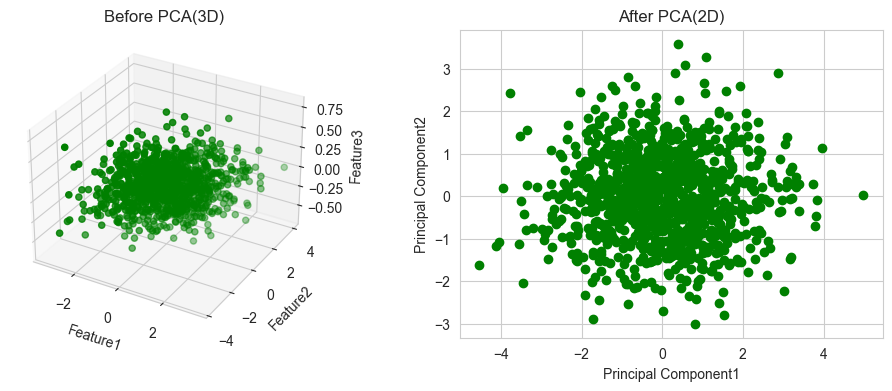

In [23]:
# 可视化
fig = plt.figure(figsize=(12, 4))

# 画出原始数据的3D分布图
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c='g')
ax1.set_title("Before PCA(3D)")
ax1.set_xlabel("Feature1")
ax1.set_ylabel("Feature2")
ax1.set_zlabel("Feature3")

# 画出降维之后的2D分布图
ax2 = fig.add_subplot(122)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c='g')
ax2.set_title("After PCA(2D)")
ax2.set_xlabel("Principal Component1")
ax2.set_ylabel("Principal Component2")

plt.show()